# 02 · Análisis Exploratorio de Datos — NYC Taxi Trips (Fase 2)

1. Carga y variables derivadas
2. Valores faltantes
3. Valores atípicos
4. Análisis de distribuciones
5. Análisis univariado
6. Análisis multivariado y relaciones entre variables
7. Hipótesis iniciales
8. Insights principales
9. Exportación del dataset limpio

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import RAW, PROCESSED, guardar_fig, outliers_iqr

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

## 1. Carga y variables derivadas

| Variable | Tipo | Descripción |
|---|---|---|
| `pickup`, `dropoff` | fecha-hora | inicio y fin del viaje |
| `passengers` | numérica discreta | pasajeros |
| `distance` | numérica | distancia (millas) |
| `fare`, `tip`, `tolls`, `total` | numéricas | tarifa, propina, peajes y total (USD) |
| `color` | categórica | taxi *yellow* o *green* |
| `payment` | categórica | *credit card* o *cash* |
| `pickup_zone`, `dropoff_zone` | categórica | zona de origen y destino (~200 valores) |
| `pickup_borough`, `dropoff_borough` | categórica | municipio de origen y destino |

In [2]:
df = pd.read_csv(RAW / "taxis.csv", parse_dates=["pickup", "dropoff"])
orig_cols = df.columns.tolist()

df["duration_min"] = (df["dropoff"] - df["pickup"]).dt.total_seconds() / 60
df["hour"] = df["pickup"].dt.hour
df["weekday"] = df["pickup"].dt.dayofweek          # 0 = lunes
df["airport"] = (df["pickup_zone"].str.contains("Airport", na=False) |
                 df["dropoff_zone"].str.contains("Airport", na=False))

num_cols = ["passengers", "distance", "fare", "tip", "tolls", "total", "duration_min"]
print(df.shape)
df.head()

(6433, 18)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duration_min,hour,weekday,airport
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.00,2.15,0.00,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.25,20,5,False
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.00,0.00,0.00,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.08,16,0,False
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.50,2.36,0.00,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.40,17,2,False
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.00,6.15,0.00,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,25.87,1,6,False
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.00,1.10,0.00,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.53,13,5,False


## 2. Valores faltantes

,n,%
dropoff_zone,45,0.70
dropoff_borough,45,0.70
payment,44,0.68
pickup_zone,26,0.40
pickup_borough,26,0.40


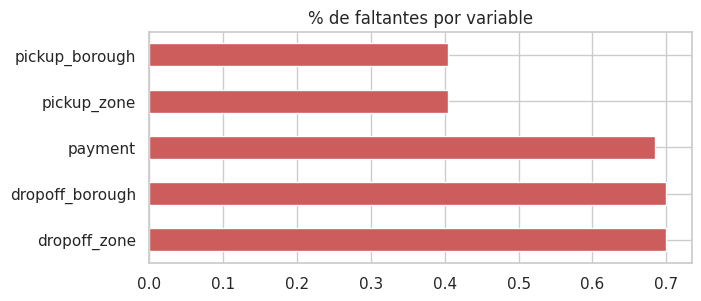

¿Zona y municipio faltan juntos? True
Filas con algún faltante: 1.4%


In [3]:
falt = pd.DataFrame({"n": df[orig_cols].isna().sum(), "%": df[orig_cols].isna().mean() * 100})
falt = falt[falt["n"] > 0].sort_values("n", ascending=False)
display(falt)

falt["%"].plot.barh(figsize=(7, 3), color="indianred", title="% de faltantes por variable")
guardar_fig("02_faltantes"); plt.show()

print("¿Zona y municipio faltan juntos?",
      (df.pickup_zone.isna() == df.pickup_borough.isna()).all() and (df.dropoff_zone.isna() == df.dropoff_borough.isna()).all())
print("Filas con algún faltante:", f"{df[orig_cols].isna().any(axis=1).mean():.1%}")

**Estrategia de tratamiento**

- El problema es pequeño: ninguna variable supera el 0,7 % y solo el 1,4 % de las filas tiene algún faltante.
- Zona y municipio faltan siempre juntos (viajes sin zona asignada por la TLC). Se imputan con la categoría `"Desconocido"` y se crea el indicador `zone_missing`.
- `payment` faltante se imputa como `"desconocido"` con indicador `payment_missing`.
- No se eliminan filas ni se imputa por moda, porque eso inflaría las categorías que ya son mayoría (Manhattan, tarjeta).

## 3. Valores atípicos

Método gráfico (boxplot) y estadístico (IQR).

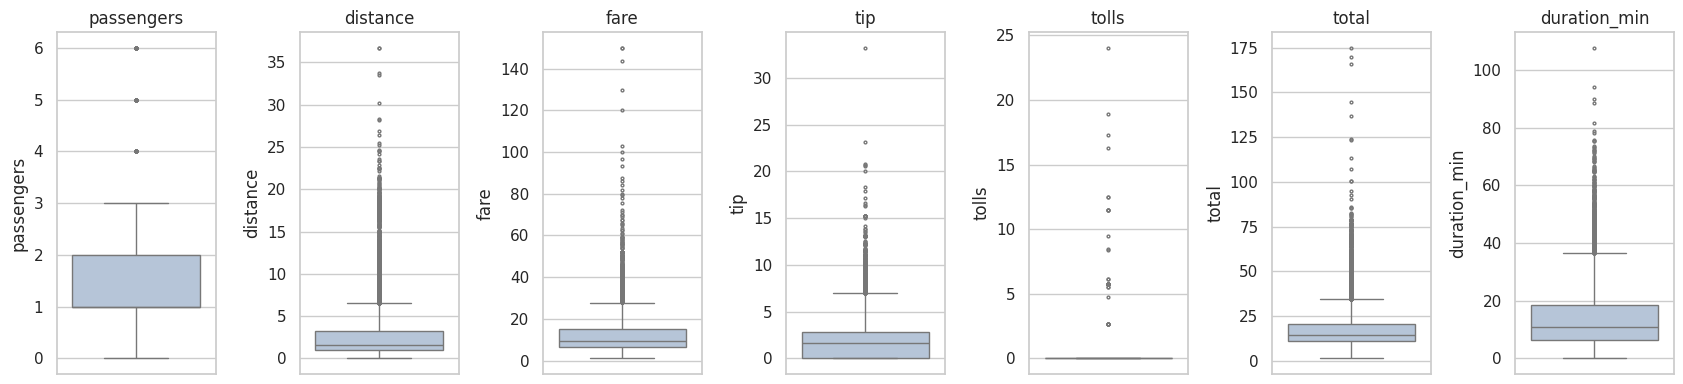

In [4]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(17, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="lightsteelblue", flierprops={"markersize": 2})
    ax.set_title(c)
plt.tight_layout(); guardar_fig("02_boxplots"); plt.show()

In [5]:
iqr = pd.DataFrame({"outliers IQR": {c: outliers_iqr(df[c]).sum() for c in num_cols}})
iqr["%"] = iqr["outliers IQR"] / len(df) * 100
display(iqr)

out_fare = outliers_iqr(df["fare"])
print(f"Outliers de tarifa que son viajes al aeropuerto: {df.loc[out_fare, 'airport'].mean():.0%}")
print("Viajes con distancia 0:", (df.distance == 0).sum(), "| duración <= 0:", (df.duration_min <= 0).sum(),
      "| 0 pasajeros:", (df.passengers == 0).sum())

,outliers IQR,%
passengers,540,8.39
distance,734,11.41
fare,592,9.20
tip,280,4.35
tolls,350,5.44
total,600,9.33
duration_min,358,5.57


Outliers de tarifa que son viajes al aeropuerto: 53%
Viajes con distancia 0: 51 | duración <= 0: 6 | 0 pasajeros: 96


**Discusión**

- La mayoría de outliers de `fare`, `distance` y `total` son **viajes reales y largos**: el 53 % de los de tarifa son viajes a aeropuertos. **Se conservan.**
- En `tolls` el IQR marca cualquier peaje distinto de 0 (Q1 = Q3 = 0); se usará como binaria (`has_toll`).
- Sí son errores los viajes con distancia 0 (51) o duración ≤ 0 (6): se marcan con `suspicious_trip`, sin eliminarlos.
- 96 viajes tienen 0 pasajeros (error de digitación del conductor): se reemplaza por 1.

## 4. Análisis de distribuciones

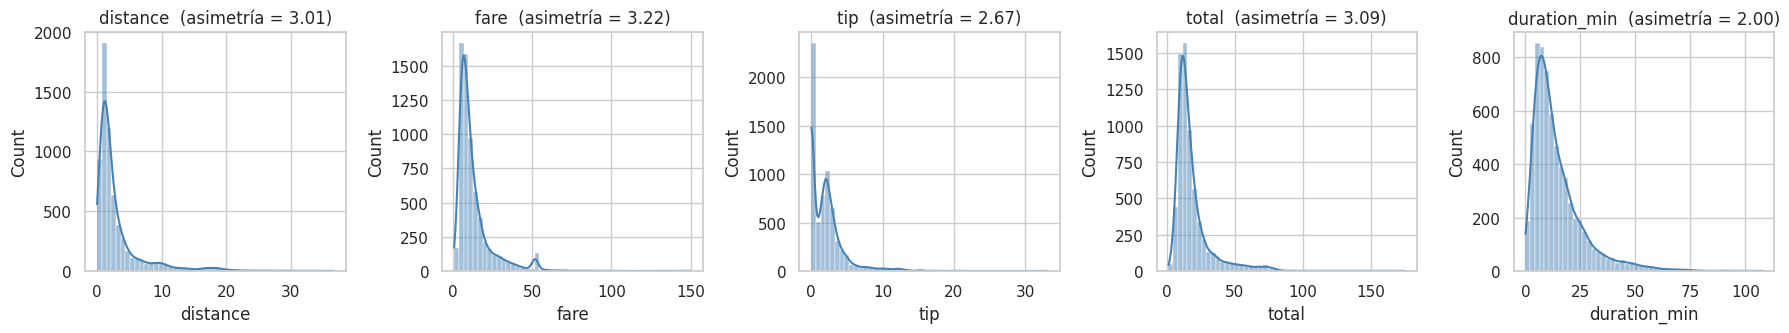

In [6]:
cont = ["distance", "fare", "tip", "total", "duration_min"]
fig, axes = plt.subplots(1, len(cont), figsize=(18, 3.5))
for ax, c in zip(axes, cont):
    sns.histplot(df[c], kde=True, bins=50, ax=ax, color="steelblue")
    ax.set_title(f"{c}  (asimetría = {df[c].skew():.2f})")
plt.tight_layout(); guardar_fig("02_distribuciones"); plt.show()

Todas tienen **sesgo positivo fuerte** (asimetría entre 2 y 3,2): muchos viajes cortos y baratos y una cola larga de viajes costosos. No son normales, así que en la Fase 3 se les aplica **transformación logarítmica (`log1p`) + estandarización**.

## 5. Análisis univariado

In [7]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
passengers,6433.00,1.54,1.20,0.00,1.00,1.00,2.00,6.00
distance,6433.00,3.02,3.83,0.00,0.98,1.64,3.21,36.70
fare,6433.00,13.09,11.55,1.00,6.50,9.50,15.00,150.00
tip,6433.00,1.98,2.45,0.00,0.00,1.70,2.80,33.20
tolls,6433.00,0.33,1.42,0.00,0.00,0.00,0.00,24.02
total,6433.00,18.52,13.82,1.30,10.80,14.16,20.30,174.82
duration_min,6433.00,14.35,11.64,0.00,6.50,10.90,18.52,107.67


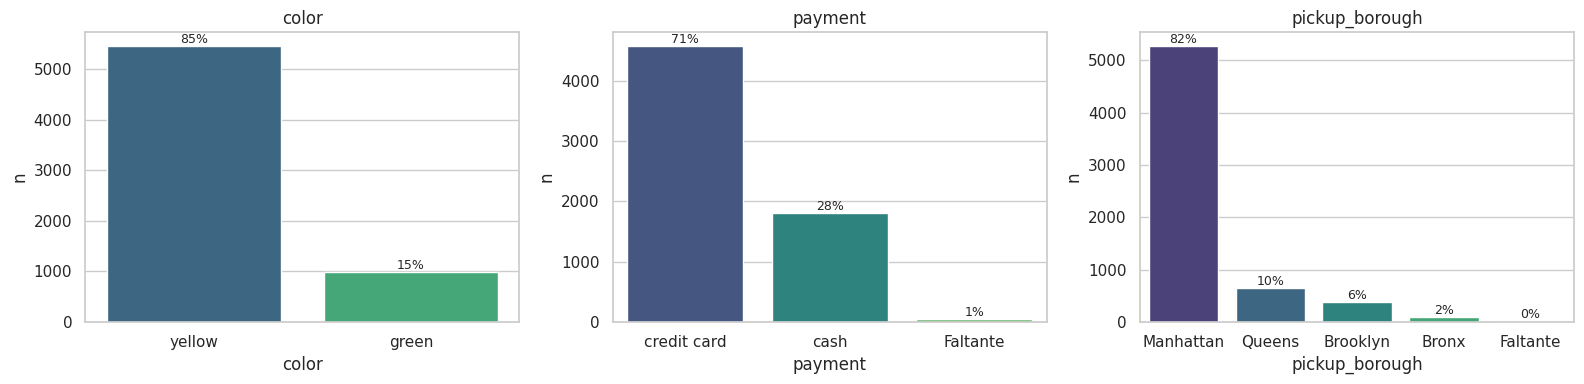

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["color", "payment", "pickup_borough"]):
    vc = df[c].fillna("Faltante").value_counts()
    sns.barplot(x=vc.index, y=vc.values, ax=ax, hue=vc.index, palette="viridis", legend=False)
    ax.set_title(c); ax.set_ylabel("n")
    for p, v in zip(ax.patches, vc.values):
        ax.annotate(f"{v/len(df):.0%}", (p.get_x() + p.get_width() / 2, v), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); guardar_fig("02_univariado_cat"); plt.show()

- Mediana de 1,6 millas, 9,5 USD de tarifa y 11 minutos: predominan los viajes cortos.
- La mayoría de viajes son de 1 pasajero.
- 85 % de los taxis son amarillos, 71 % paga con tarjeta y 82 % de las recogidas son en Manhattan.

## 6. Análisis multivariado y relaciones entre variables

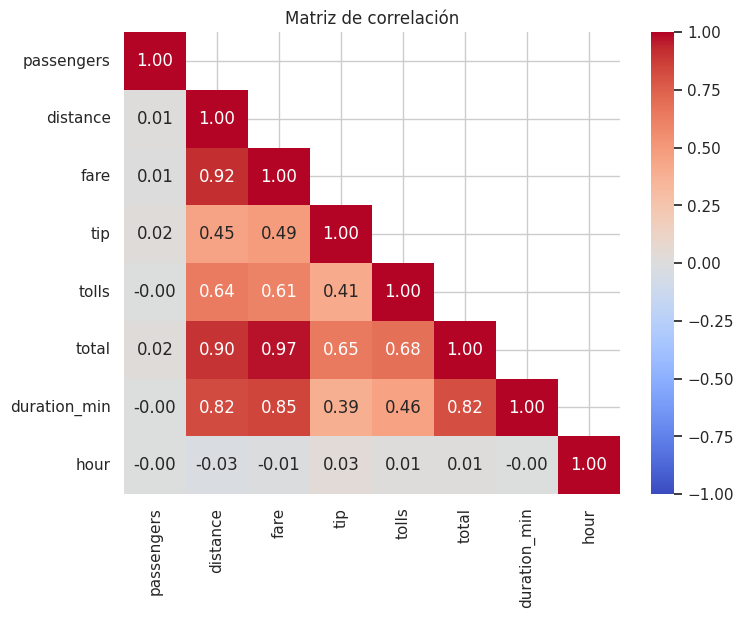

In [9]:
corr = df[num_cols + ["hour"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            mask=np.triu(np.ones_like(corr, bool), k=1), ax=ax)
ax.set_title("Matriz de correlación")
guardar_fig("02_correlaciones"); plt.show()

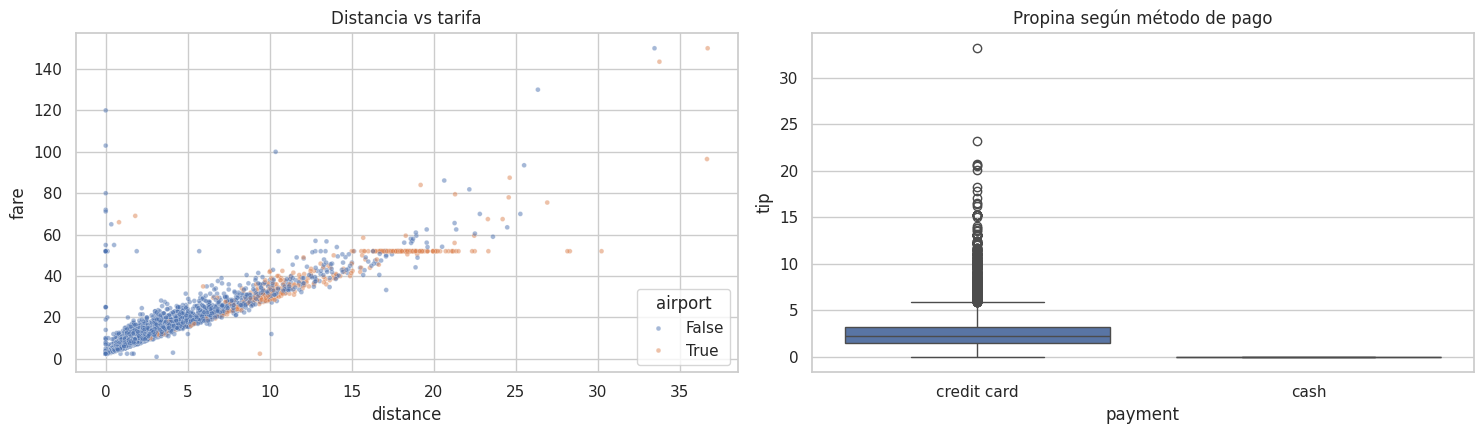

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.scatterplot(data=df, x="distance", y="fare", hue="airport", alpha=0.5, s=12, ax=axes[0])
axes[0].set_title("Distancia vs tarifa")
sns.boxplot(data=df, x="payment", y="tip", hue="payment", legend=False, ax=axes[1])
axes[1].set_title("Propina según método de pago")
plt.tight_layout(); guardar_fig("02_relaciones"); plt.show()

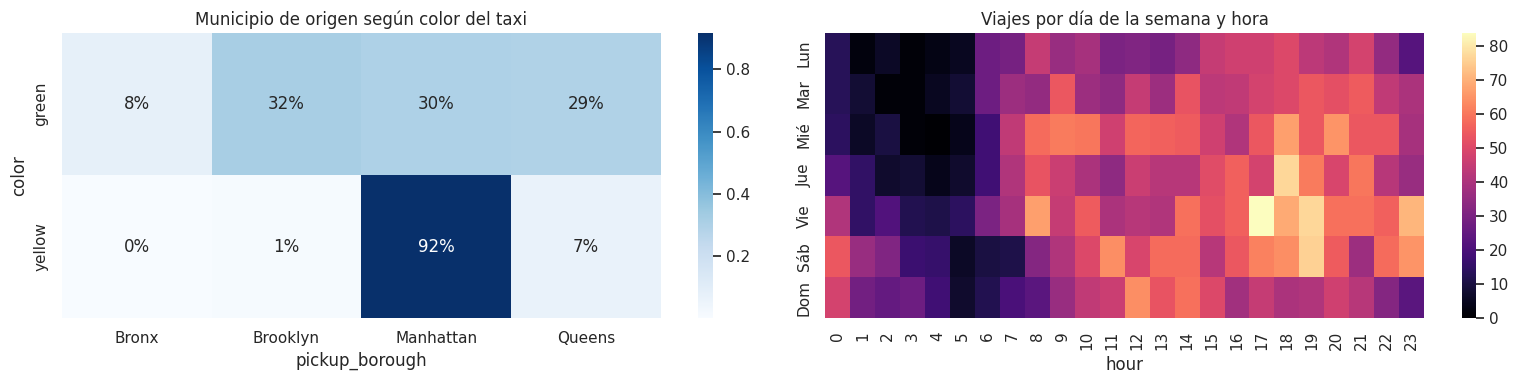

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.heatmap(pd.crosstab(df.color, df.pickup_borough, normalize="index"), annot=True, fmt=".0%", cmap="Blues", ax=axes[0])
axes[0].set_title("Municipio de origen según color del taxi")
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
hw = pd.crosstab(df.weekday, df.hour); hw.index = dias
sns.heatmap(hw, cmap="magma", ax=axes[1])
axes[1].set_title("Viajes por día de la semana y hora")
plt.tight_layout(); guardar_fig("02_crosstabs"); plt.show()

- `distance`, `fare`, `total` y `duration_min` están **muy correlacionadas** (r > 0,8): son redundantes.
- La propina en efectivo es **siempre 0**, mientras que con tarjeta tiene una mediana de 2,2 USD.
- Los taxis verdes recogen fuera de Manhattan (Brooklyn, Queens, Manhattan norte); los amarillos, casi todo en Manhattan.
- Entre semana la demanda sube en la mañana (8–9 h) y alcanza el máximo en la tarde-noche (18–19 h); los fines de semana hay más viajes de madrugada.

## 7. Hipótesis iniciales

A partir de los patrones anteriores se plantean hipótesis que pueden verificarse con el dataset:

1. **La tarifa depende principalmente de la distancia recorrida.**
2. **La propina registrada depende del método de pago**, porque el sistema no captura la propina en efectivo.
3. **Los viajes a aeropuertos tienen tarifas mayores** que el resto.
4. **El color del taxi está asociado al municipio de origen.**
5. **La demanda de taxis varía según la hora y el día de la semana.**

In [12]:
print("Correlación distancia–tarifa:", round(df.distance.corr(df.fare), 2))
print("Propina = 0 en efectivo:", f"{(df.loc[df.payment == 'cash', 'tip'] == 0).mean():.0%}")
print("Mediana de tarifa  aeropuerto / resto:", df.loc[df.airport, "fare"].median(), "/", df.loc[~df.airport, "fare"].median())

Correlación distancia–tarifa: 0.92
Propina = 0 en efectivo: 100%
Mediana de tarifa  aeropuerto / resto: 36.0 / 9.0


## 8. Insights principales

**Patrones**

1. La tarifa es casi función de la distancia (r = 0,92); distancia, tarifa, total y duración son redundantes.
2. La propina en efectivo siempre es 0: es una limitación del registro, no un comportamiento de los usuarios.
3. Los viajes a aeropuertos (~6 %) explican la mayoría de outliers de tarifa (mediana 36 vs 9 USD).
4. Manhattan concentra el 82 % de las recogidas; los taxis verdes operan fuera del centro.
5. La demanda tiene un patrón claro por hora y día: picos entre semana a las 8–9 h y 18–19 h.

**Problemas de calidad:** faltantes < 1 % en pago y zonas; 96 viajes con 0 pasajeros; 51 con distancia 0; 6 con duración ≤ 0; `tip` no es comparable entre métodos de pago.

**Líneas de análisis futuras:** modelo de predicción de tarifa, modelo de propina solo con pagos con tarjeta y segmentación de viajes.

## 9. Exportación del dataset limpio

In [13]:
clean = df.copy()
clean["zone_missing"] = (clean.pickup_zone.isna() | clean.dropoff_zone.isna()).astype(int)
clean["payment_missing"] = clean.payment.isna().astype(int)
for c in ["pickup_zone", "dropoff_zone", "pickup_borough", "dropoff_borough"]:
    clean[c] = clean[c].fillna("Desconocido")
clean["payment"] = clean["payment"].fillna("desconocido")
clean.loc[clean.passengers == 0, "passengers"] = 1
clean["suspicious_trip"] = ((clean.distance == 0) | (clean.duration_min <= 0)).astype(int)
clean["has_toll"] = (clean.tolls > 0).astype(int)

print("Faltantes restantes:", clean.isna().sum().sum())
PROCESSED.mkdir(parents=True, exist_ok=True)
clean.to_csv(PROCESSED / "taxis_clean.csv", index=False)
print("Guardado:", clean.shape)

Faltantes restantes: 0
Guardado: (6433, 22)
